## Import the libraries

In [23]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier

import joblib

## Load the data set


In [24]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()


,LineOfCode,IsHTTPS,URLLength,CharContinuationRate,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,LargestLineLength,label
0,558,1,31,1.000000,0.581,0,0.0,1,0.032,9381,1
1,618,1,23,0.666667,0.391,0,0.0,2,0.087,9381,1
2,467,1,29,0.866667,0.517,0,0.0,2,0.069,682,1
3,6356,1,26,1.000000,0.500,0,0.0,1,0.038,26824,1
4,6089,1,33,1.000000,0.606,0,0.0,1,0.030,28404,1


In [25]:
print(df.shape)

(235795, 11)


## seperate features


In [26]:
TARGET = "label"

X = df.drop(columns=[TARGET])

y = df[TARGET]

## Train/Test Split


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Training baseline XG boost


In [28]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Prediction


In [29]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## Metrics


In [30]:
baseline_accuracy = accuracy_score(y_test,y_pred)

baseline_precision = precision_score(y_test,y_pred)

baseline_recall = recall_score(y_test,y_pred)

baseline_f1 = f1_score(y_test,y_pred)

baseline_roc = roc_auc_score(y_test,y_prob)

In [31]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc
    ]
})

results

,Metric,Value
0,Accuracy,0.999788
1,Precision,0.999778
2,Recall,0.999852
3,F1 Score,0.999815
4,ROC-AUC,0.999996


## Confusion Matrix


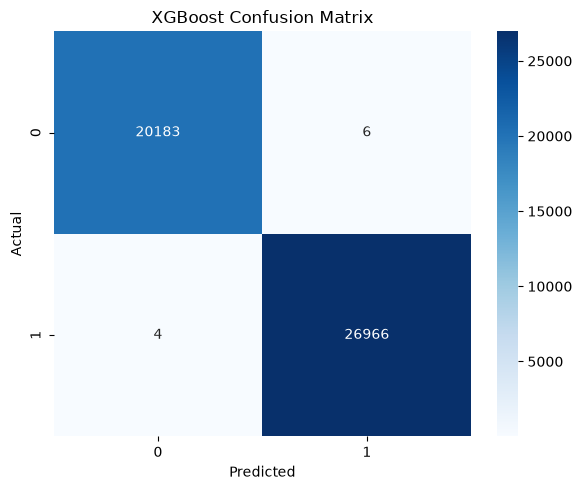

In [32]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../reports/figures/confusion_matrix_xgb.png")

plt.show()

## Classification Report


In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



## ROC curve


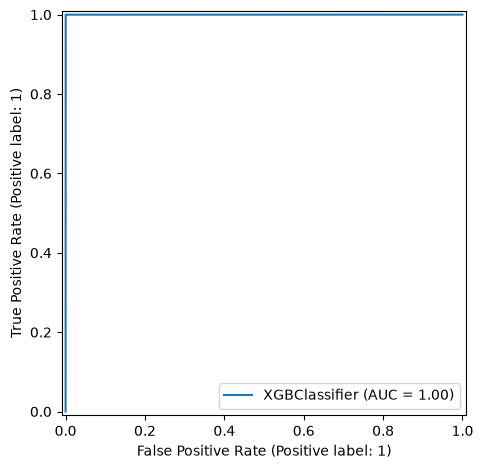

In [34]:
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.tight_layout()

plt.savefig("../reports/figures/roc_xgb.png")

plt.show()

## Feature importance


<Figure size 1200x800 with 0 Axes>

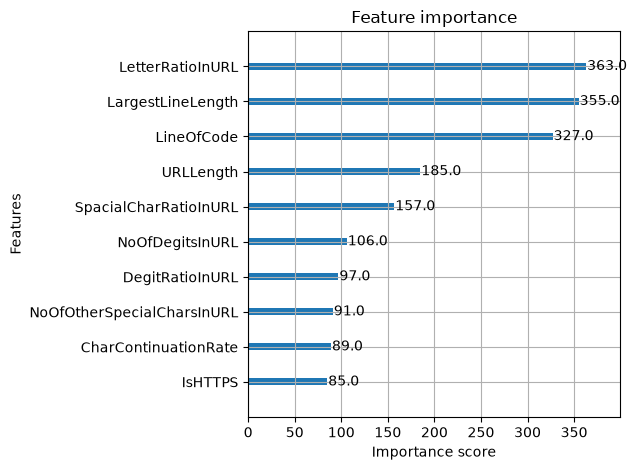

In [35]:
from xgboost import plot_importance

plt.figure(figsize=(12,8))

plot_importance(
    model,
    max_num_features=20
)

plt.tight_layout()

plt.savefig("../reports/figures/xgb_feature_importance.png")

plt.show()

In [36]:
# save the model
joblib.dump(
    model,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']

In [37]:
#save metrics
results.to_csv(
    "../results/xgb_metrics.csv",
    index=False
)

In [38]:
print(X.columns)

Index(['LineOfCode', 'IsHTTPS', 'URLLength', 'CharContinuationRate',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
       'LargestLineLength'],
      dtype='str')


# Summary

The baseline XGBoost model was trained using the selected URL features.

The model was evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

The trained model was saved for later deployment and ensemble learning.

Next Step:
Hyperparameter tuning using RandomizedSearchCV.

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.99968193 0.99978795 0.99978795 0.99980916 0.99985157]
0.9997837104264298


# Tunning the parameters for xg boost


In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import pandas as pd
from xgboost import XGBClassifier

### defining the parameters

In [41]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0, 0.5)
}

### creating the base model


In [42]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

### create randomized search


In [43]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,                 # 20 random combinations
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

### train

In [44]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.8123620356542087, gamma=0.4753571532049581, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.8337498258560773; total time=   1.2s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.4753571532049581, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.8337498258560773; total time=   1.4s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.4753571532049581, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.8337498258560773; total time=   1.5s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.4753571532049581, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.8337498258560773; total time=   1.4s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.4753571532049581, learning_rate=0.15639878836228102, max

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x120737ed0>, 'gamma': <scipy.stats....t 0x120297bb0>, 'learning_rate': <scipy.stats....t 0x1202827b0>, 'max_depth': <scipy.stats....t 0x120737c50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosi

### best parameters

In [45]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'colsample_bytree': np.float64(0.7935133228268232), 'gamma': np.float64(0.2600340105889054), 'learning_rate': np.float64(0.11934205586865593), 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 290, 'subsample': np.float64(0.9526854323784995)}


### best score

In [46]:
print("Best CV Accuracy:")
print(random_search.best_score_)

Best CV Accuracy:
0.9997455420153532


### Training the tuned model

In [47]:
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.7935133228268232)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluating the tuned model

In [48]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [49]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

### saving the tuned model

In [50]:
import joblib

joblib.dump(
    best_model,
    "../models/xgboost_tuned.pkl"
)

['../models/xgboost_tuned.pkl']

### saving the results

In [51]:
tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

tuned_results.to_csv(
    "../results/xgb_tuned_metrics.csv",
    index=False
)

# Baselive VS Tuned

In [52]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc
    ],
    "Tuned": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.999788,0.999788
1,Precision,0.999778,0.999778
2,Recall,0.999852,0.999852
3,F1,0.999815,0.999815
4,ROC-AUC,0.999996,0.999995
